In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [ ]:
tcs = yf.download("TCS.NS", start="2018-01-01")
if isinstance(tcs.columns, pd.MultiIndex):
    tcs.columns = tcs.columns.get_level_values(0)
tcs.tail()

/tmp/ipykernel_5045/3344991163.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs = yf.download("TCS.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,2527.399902,2560.000000,2505.000000,2530.000000,3653428
2026-03-10,2513.100098,2545.199951,2490.100098,2541.000000,4323710
2026-03-11,2464.899902,2521.000000,2460.100098,2508.100098,2720664
2026-03-12,2442.399902,2472.899902,2436.000000,2459.800049,2752075
2026-03-13,2410.500000,2445.899902,2397.000000,2437.000000,2466012


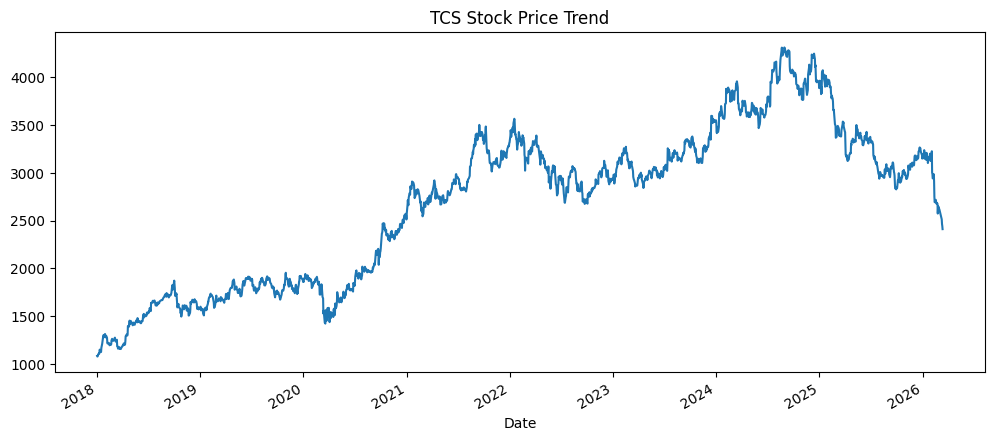

In [ ]:
tcs.isnull().sum()

tcs["Close"].plot(figsize=(12,5))
plt.title("TCS Stock Price Trend")
plt.show()

Text(0.5, 1.0, 'TCS Daily Returns')

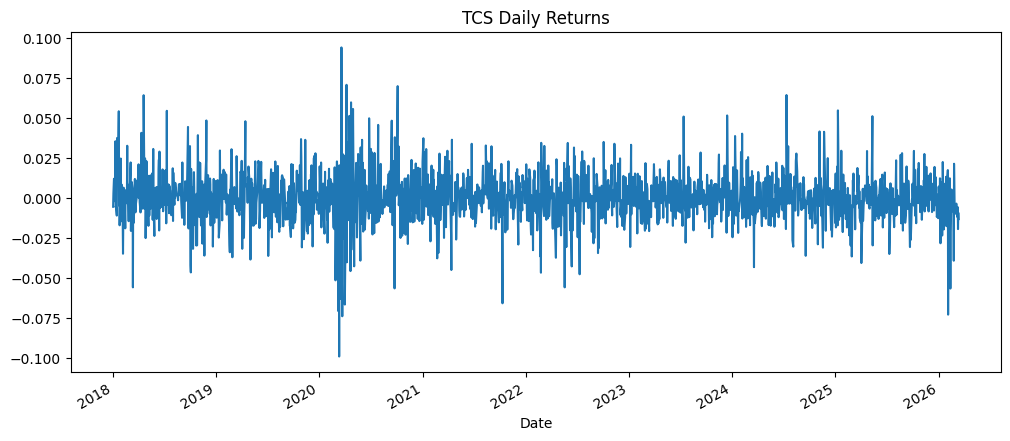

In [ ]:
tcs["simple_return"] = tcs["Close"].pct_change()
tcs["log_return"] = np.log(tcs["Close"]/tcs["Close"].shift(1))
tcs["log_return"].plot(figsize=(12,5))
plt.title("TCS Daily Returns")

# Volatility Analysis


In [ ]:
daily_vol = tcs["log_return"].std()
annual_vol = daily_vol * np.sqrt(252)

print("Daily Volatility:", daily_vol)
print("Annual Volatility:", annual_vol)

Daily Volatility: 0.015156392191341328
Annual Volatility: 0.24060026706750265


# Sharpe Ratio

In [ ]:
risk_free_rate = 0.03

annual_return = tcs["log_return"].mean()*252

sharpe_ratio = (annual_return - risk_free_rate) / annual_vol

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 0.2887746513621324


# Beta Calculation (Market Risk)

In [ ]:
# Download NIFTY
market = yf.download("^NSEI", start="2018-01-01")

market.index = market.index.tz_localize(None)
tcs.index = tcs.index.tz_localize(None)

# Market log returns
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

# Combine datasets
df = pd.concat(
    [tcs["log_return"], market["market_return"]],
    axis=1
).dropna()

# Regression
X = sm.add_constant(df["market_return"])
y = df["log_return"]

model = sm.OLS(y, X).fit()

beta = model.params["market_return"]

print("Beta:", beta)

/tmp/ipykernel_5045/3543499974.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed

Beta: 0.700283830345316


# Value at Risk (VaR)

In [ ]:
VaR_95 = np.percentile(tcs["log_return"].dropna(),5)

print("Value at Risk (95%):", VaR_95)

Value at Risk (95%): -0.02220076330884642


# Stationarity Test (ADF)


In [ ]:
# remove NaN and infinite values
log_returns = tcs["log_return"].replace([np.inf, -np.inf], np.nan).dropna()

result = adfuller(log_returns)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is NOT stationary")

ADF Statistic: -9.68396138487241
p-value: 1.184144536341621e-16
Series is stationary


# ARIMA Model

In [ ]:
model = ARIMA(tcs["log_return"].dropna(), order=(1,0,1))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2025
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5611.067
Date:                Sat, 14 Mar 2026   AIC                         -11214.135
Time:                        11:56:05   BIC                         -11191.682
Sample:                             0   HQIC                        -11205.896
                               - 2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.187      0.235      -0.000       0.001
ar.L1          0.1924      0.751      0.256      0.798      -1.280       1.665
ma.L1         -0.2122      0.748     -0.284      0.7

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Forecast Future Returns

In [ ]:
forecast = model_fit.forecast(steps=5)
print("Next 5 day forecast:")
print(forecast)

Next 5 day forecast:
2025    0.000720
2026    0.000456
2027    0.000405
2028    0.000395
2029    0.000393
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Forecast Visualization

Text(0.5, 1.0, 'ARIMA Forecast')

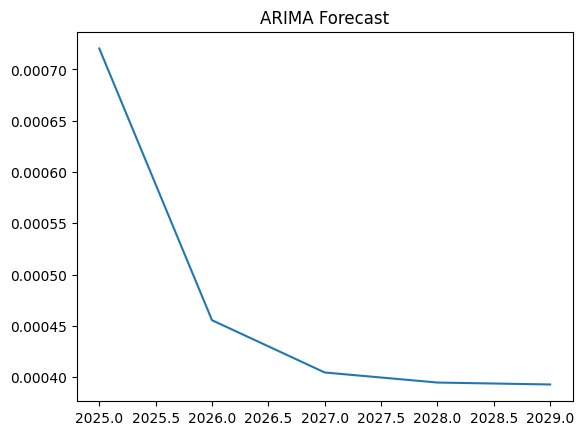

In [ ]:
plt.plot(forecast)
plt.title("ARIMA Forecast")

# Return Distribution

Text(0.5, 1.0, 'Distribution of Returns')

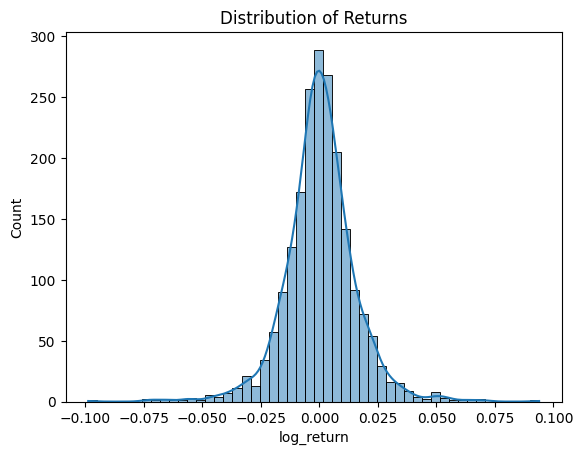

In [ ]:
sns.histplot(tcs["log_return"].dropna(), bins=50,kde=True)
plt.title("Distribution of Returns")

# Cumulative Returns

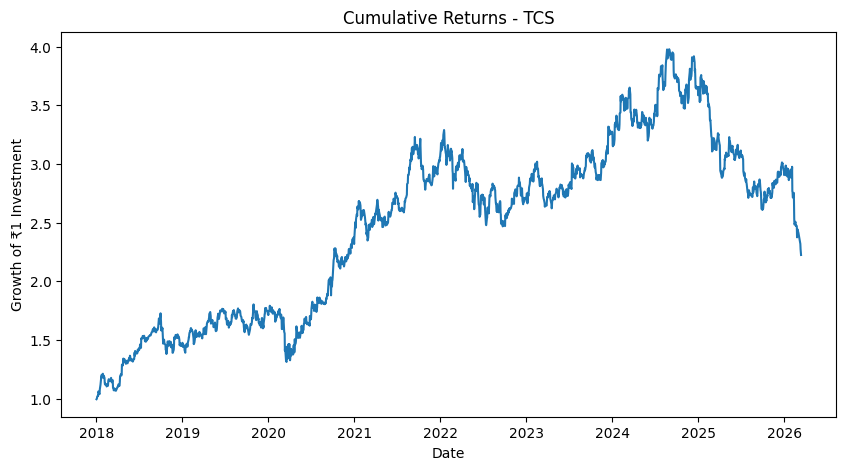

In [ ]:
tcs["cum_returns"] = (1 + tcs["simple_return"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(tcs["cum_returns"])
plt.title("Cumulative Returns - TCS")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Investment")
plt.show()

# Maximum Drawdown

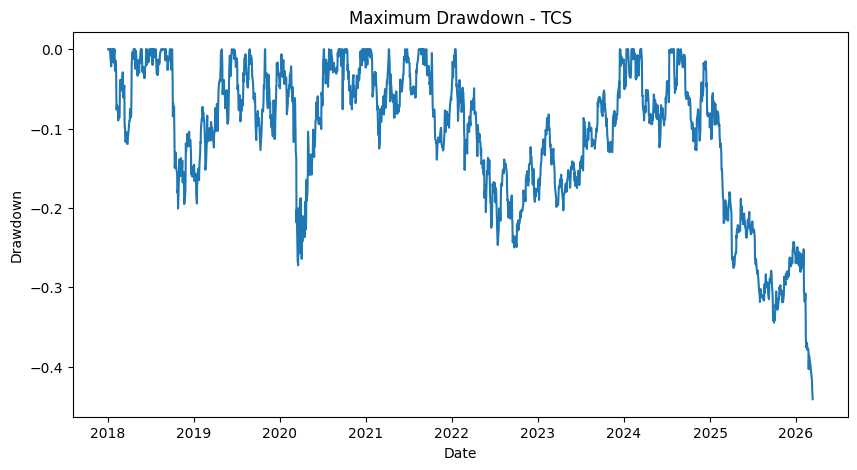

Maximum Drawdown: -0.44092491534946254


In [ ]:
cum_returns = (1 + tcs["simple_return"]).cumprod()
rolling_max = cum_returns.cummax()

drawdown = cum_returns / rolling_max - 1

plt.figure(figsize=(10,5))
plt.plot(drawdown)
plt.title("Maximum Drawdown - TCS")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

max_drawdown = drawdown.min()
print("Maximum Drawdown:", max_drawdown)

# Market Return Calculation (NIFTY)

In [ ]:
market = yf.download("^NSEI", start="2018-01-01")

market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

market.dropna(inplace=True)

/tmp/ipykernel_5045/3475558658.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


# Performance Analysis using Pyfolio

In this section we analyze the performance of TCS Industries Stock using the Pyfolio library.

We compare the performance of TCS Industries against NIFTY 50 index

In [ ]:
!pip install pyfolio-reloaded

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download Benchmark Data (NIFTY 50)

To evaluate the performance of the stock relative to the market, we use the NIFTY 50 index as a benchmark.


In [ ]:
# Download NIFTY 50 index data
nifty = yf.download("^NSEI", start="2018-01-01")

# Fix column structure if MultiIndex appears
if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

# Remove timezone mismatch
nifty.index = nifty.index.tz_localize(None)

nifty.head()

/tmp/ipykernel_5045/1956627339.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,10442.200195,10495.200195,10404.650391,10477.549805,153400
2018-01-03,10443.200195,10503.599609,10429.549805,10482.650391,167300
2018-01-04,10504.799805,10513.000000,10441.450195,10469.400391,174900
2018-01-05,10558.849609,10566.099609,10520.099609,10534.250000,180900
2018-01-08,10623.599609,10631.200195,10588.549805,10591.700195,169000


# Compute Benchmark Returns

We compute log returns for the benchmark index to ensure consistency with the stock returns used earlier.

In [ ]:
# Calculate NIFTY log returns
nifty["benchmark_return"] = np.log(
    nifty["Close"] / nifty["Close"].shift(1)
)

# Remove missing values
nifty.dropna(inplace=True)

nifty[["Close","benchmark_return"]].head()

Price,Close,benchmark_return
Date,,
2018-01-03,10443.200195,0.000096
2018-01-04,10504.799805,0.005881
2018-01-05,10558.849609,0.005132
2018-01-08,10623.599609,0.006114
2018-01-09,10637.000000,0.001261


# Prepare Stock Returns

Pyfolio requires a clean return series indexed by datetime.

We remove timezone information and ensure the data is aligned properly.

In [ ]:
# Ensure timezone consistency
tcs.index = tcs.index.tz_localize(None)

# Compute stock log returns
tcs["log_return"] = np.log(
    tcs["Close"] / tcs["Close"].shift(1)
)

# Remove NaN values
tcs.dropna(inplace=True)

tcs[["Close","log_return"]].head()

Price,Close,log_return
Date,,
2018-02-14,1195.648804,-0.018881
2018-02-15,1201.417603,0.004813
2018-02-16,1204.374390,0.002458
2018-02-19,1200.494141,-0.003227
2018-02-20,1209.179077,0.007208


# Generate Pyfolio Performance Report

The Pyfolio tear sheet provides a comprehensive summary of portfolio performance including:

- cumulative returns
- drawdown periods
- rolling Sharpe ratio
- volatility analysis
- return distribution

/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.302%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-01
End date,2026-03-13
Total months,96
,Backtest
Annual return,7.302%
Cumulative returns,76.224%
Annual volatility,24.06%
Sharpe ratio,0.41
Calmar ratio,0.16
Stability,0.68
Max drawdown,-45.993%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,45.99,2024-08-30,2026-03-13,NaT,NaN
1,28.74,2019-10-31,2020-04-03,2020-09-11,227
2,26.59,2022-01-17,2022-09-23,2024-02-05,536
3,20.45,2018-10-01,2018-10-26,2019-10-30,283
4,14.26,2021-09-15,2021-10-29,2022-01-17,89


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


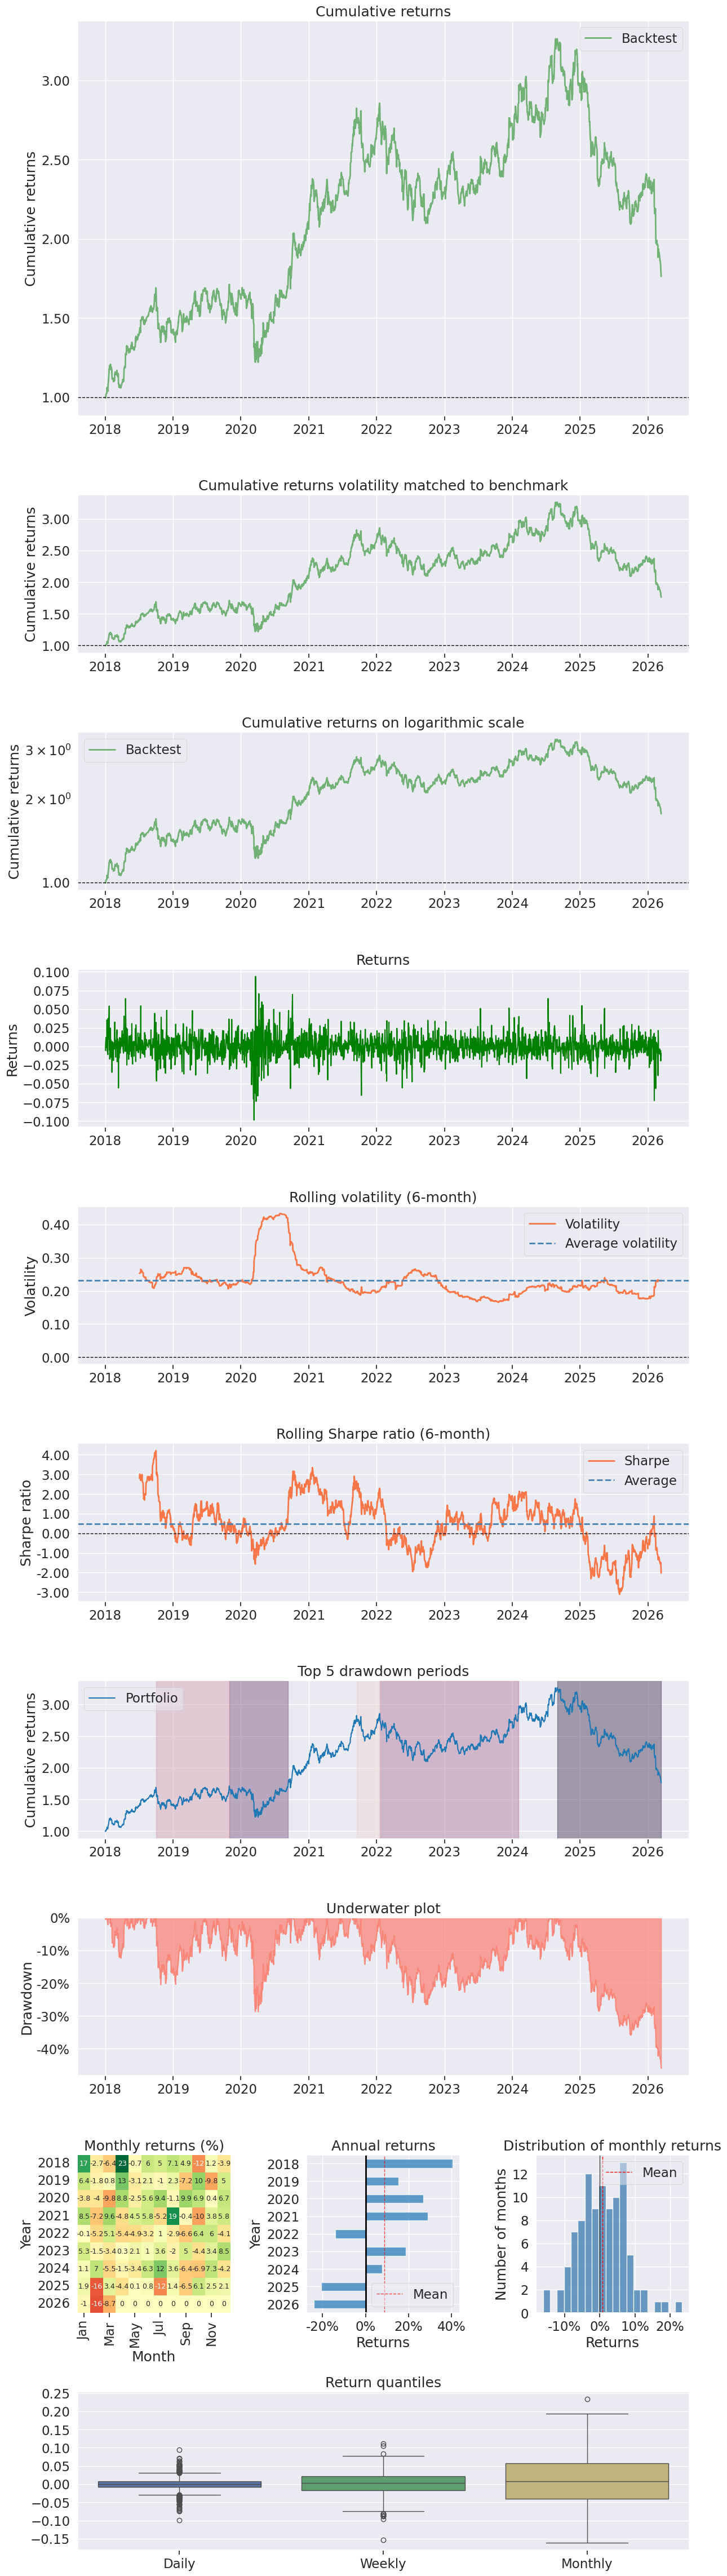

In [ ]:
import pyfolio as pf

returns = tcs["log_return"]

pf.create_returns_tear_sheet(returns)

# Rolling Volatility

Rolling Volatility helps visualize how risk evolves over time

<Axes: title={'center': 'Rolling volatility (6-month)'}, ylabel='Volatility'>

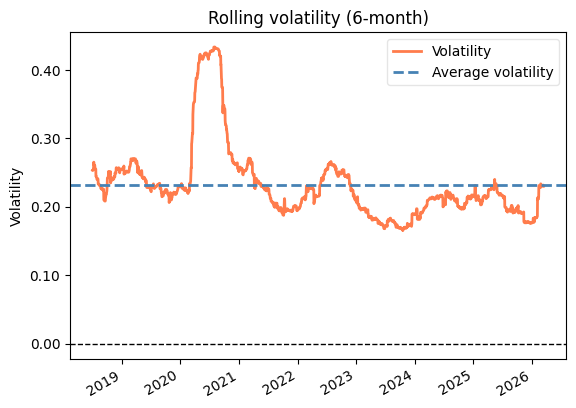

In [ ]:
pf.plotting.plot_rolling_volatility(returns)

# Rolling Sharpe Ratio

This plot shows how the risk-adjusted return changes through time

<Axes: title={'center': 'Rolling Sharpe ratio (6-month)'}, ylabel='Sharpe ratio'>

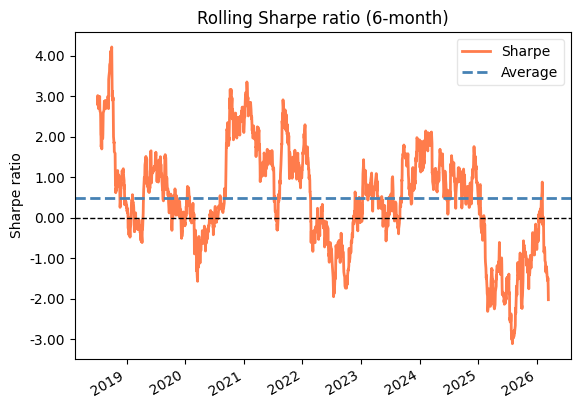

In [ ]:
pf.plotting.plot_rolling_sharpe(returns)

# Drawdown Analysis

Drawdown represents the decline from a historical peak.

This helps identify periods of large losses.

<Axes: title={'center': 'Top 10 drawdown periods'}, ylabel='Cumulative returns'>

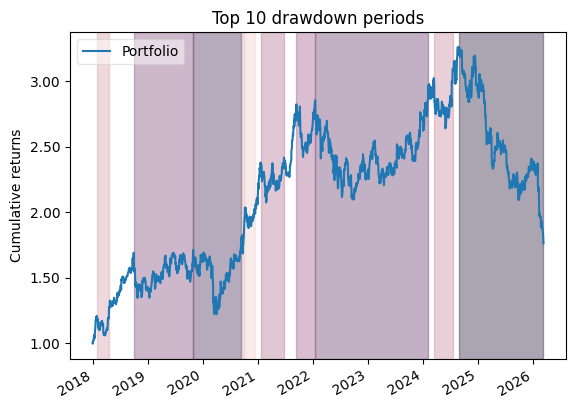

In [ ]:
pf.plotting.plot_drawdown_periods(returns)

# Rolling Metrics

Text(0.5, 1.0, '30-Day Rolling Volatility')

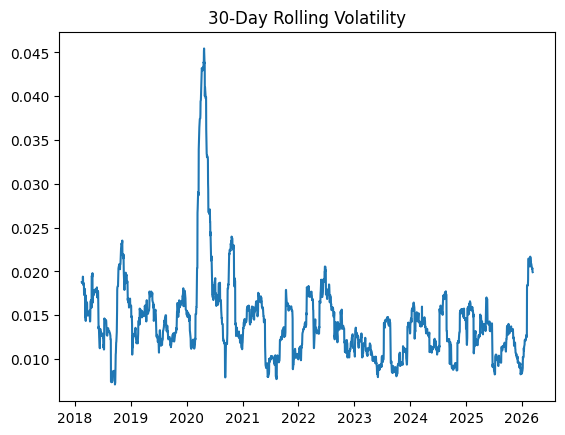

In [ ]:
tcs["rolling_vol"] = tcs["log_return"].rolling(30).std()

plt.plot(tcs["rolling_vol"])
plt.title("30-Day Rolling Volatility")

# Maximum Drawdown

Text(0.5, 1.0, 'Maximum Drawdown')

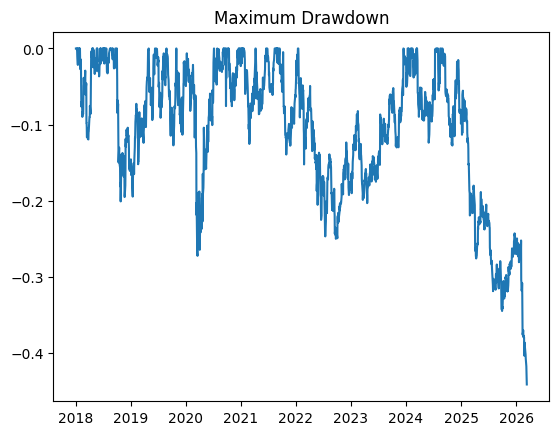

In [ ]:
cum_returns = (1 + tcs["simple_return"]).cumprod()
rolling_max = cum_returns.cummax()
drawdown = cum_returns / rolling_max - 1

plt.plot(drawdown)
plt.title("Maximum Drawdown")

# Cumulative Return

Text(0.5, 1.0, 'Cumulative Returns')

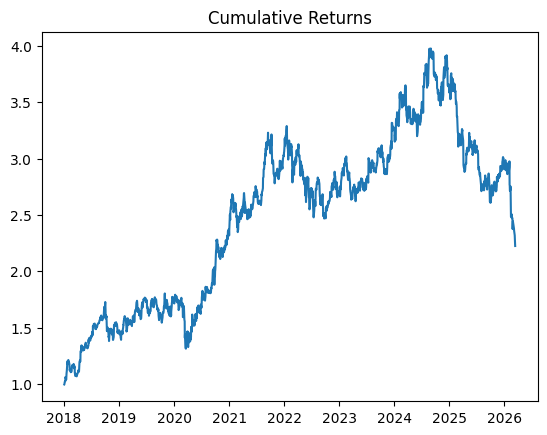

In [ ]:
cum_returns = (1 + tcs["simple_return"]).cumprod()

plt.plot(cum_returns)
plt.title("Cumulative Returns")